In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install timm einops -q
print("✅ Libraries ready")

Mounted at /content/drive
✅ Libraries ready


In [2]:
import os

REAL_PATH = "/content/drive/MyDrive/real_deepfake"
FAKE_PATH = "/content/drive/MyDrive/fake_deepfake"

real_files = [f for f in os.listdir(REAL_PATH)
              if f.lower().endswith(('.jpg','.jpeg','.png'))]
fake_files = [f for f in os.listdir(FAKE_PATH)
              if f.lower().endswith(('.jpg','.jpeg','.png'))]

print(f"✅ Real images found : {len(real_files)}")
print(f"✅ Fake images found : {len(fake_files)}")
print(f"\nSample real files: {real_files[:3]}")
print(f"Sample fake files: {fake_files[:3]}")

✅ Real images found : 0
✅ Fake images found : 0

Sample real files: []
Sample fake files: []


In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Step 1 — See exactly what's inside MyDrive
print("=== MyDrive contents ===")
for item in os.listdir("/content/drive/MyDrive"):
    print(repr(item))  # repr() shows hidden spaces/special chars exactly

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== MyDrive contents ===
'Colab Notebooks'
'real_deepfake'
'fake_deepfake'


In [4]:
# Step 2 — See exactly what's inside frp folder
print("=== frp folder contents ===")
for item in os.listdir("/content/drive/MyDrive/frp"):
    print(repr(item))

=== frp folder contents ===


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/frp'

In [5]:
import os

# ── CORRECTED EXACT PATHS ────────────────────────────────────────
REAL_PATH = "/content/drive/MyDrive/real_deepfake"
FAKE_PATH = "/content/drive/MyDrive/fake_deepfake"

EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

real_files = [f for f in os.listdir(REAL_PATH)
              if f.lower().endswith(EXTENSIONS)]
fake_files = [f for f in os.listdir(FAKE_PATH)
              if f.lower().endswith(EXTENSIONS)]

print(f"✅ Real images found : {len(real_files)}")
print(f"✅ Fake images found : {len(fake_files)}")
print(f"\nSample real files : {real_files[:3]}")
print(f"Sample fake files : {fake_files[:3]}")

✅ Real images found : 0
✅ Fake images found : 0

Sample real files : []
Sample fake files : []


In [6]:
import os

REAL_PATH = "/content/drive/MyDrive/real_deepfake"
FAKE_PATH = "/content/drive/MyDrive/fake_deepfake"

real_files = os.listdir(REAL_PATH)
fake_files = os.listdir(FAKE_PATH)

print(f"✅ Real videos found : {len(real_files)}")
print(f"✅ Fake videos found : {len(fake_files)}")
print(f"\nSample real : {real_files[:3]}")
print(f"Sample fake : {fake_files[:3]}")

✅ Real videos found : 50
✅ Fake videos found : 50

Sample real : ['914.mp4', '956.mp4', '955.mp4']
Sample fake : ['601_653.mp4', '602_397.mp4', '600_505.mp4']


In [7]:
!pip install opencv-python -q
print("✅ OpenCV ready")

✅ OpenCV ready


In [8]:
import cv2
import os

REAL_PATH    = "/content/drive/MyDrive/real_deepfake"
FAKE_PATH    = "/content/drive/MyDrive/fake_deepfake"

# Frames will be saved here locally in Colab
REAL_FRAMES  = "/content/frames/real"
FAKE_FRAMES  = "/content/frames/fake"

os.makedirs(REAL_FRAMES, exist_ok=True)
os.makedirs(FAKE_FRAMES, exist_ok=True)


def extract_frames(video_folder, save_folder, frames_per_video=10, label=""):
    """
    Extracts fixed number of evenly spaced frames from each video.
    frames_per_video=10 → 50 videos × 10 = 500 frames
    """
    video_files = [f for f in os.listdir(video_folder)
                   if f.lower().endswith(('.mp4', '.avi', '.mov', '.mkv'))]

    total_saved = 0

    for vid_idx, vid_file in enumerate(video_files):
        vid_path = os.path.join(video_folder, vid_file)
        cap      = cv2.VideoCapture(vid_path)

        if not cap.isOpened():
            print(f"  ⚠️  Could not open: {vid_file}")
            continue

        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        # Pick evenly spaced frame indices
        if total_frames < frames_per_video:
            indices = list(range(total_frames))
        else:
            step    = total_frames // frames_per_video
            indices = [i * step for i in range(frames_per_video)]

        saved = 0
        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                fname = f"{os.path.splitext(vid_file)[0]}_frame{idx:04d}.jpg"
                cv2.imwrite(os.path.join(save_folder, fname), frame)
                saved += 1

        cap.release()
        total_saved += saved
        print(f"  [{label}] {vid_file} → {saved} frames extracted")

    print(f"\n✅ Total {label} frames saved: {total_saved}")
    return total_saved


print("⏳ Extracting REAL frames...")
extract_frames(REAL_PATH, REAL_FRAMES, frames_per_video=10, label="REAL")

print("\n⏳ Extracting FAKE frames...")
extract_frames(FAKE_PATH, FAKE_FRAMES, frames_per_video=10, label="FAKE")

⏳ Extracting REAL frames...
  [REAL] 914.mp4 → 10 frames extracted
  [REAL] 956.mp4 → 10 frames extracted
  [REAL] 955.mp4 → 10 frames extracted
  [REAL] 958.mp4 → 10 frames extracted
  [REAL] 952.mp4 → 10 frames extracted
  [REAL] 957.mp4 → 10 frames extracted
  [REAL] 959.mp4 → 10 frames extracted
  [REAL] 953.mp4 → 10 frames extracted
  [REAL] 950.mp4 → 10 frames extracted
  [REAL] 960.mp4 → 10 frames extracted
  [REAL] 954.mp4 → 10 frames extracted
  [REAL] 951.mp4 → 10 frames extracted
  [REAL] 966.mp4 → 10 frames extracted
  [REAL] 968.mp4 → 10 frames extracted
  [REAL] 977.mp4 → 10 frames extracted
  [REAL] 962.mp4 → 10 frames extracted
  [REAL] 974.mp4 → 10 frames extracted
  [REAL] 963.mp4 → 10 frames extracted
  [REAL] 965.mp4 → 10 frames extracted
  [REAL] 971.mp4 → 10 frames extracted
  [REAL] 969.mp4 → 10 frames extracted
  [REAL] 970.mp4 → 10 frames extracted
  [REAL] 978.mp4 → 10 frames extracted
  [REAL] 975.mp4 → 10 frames extracted
  [REAL] 964.mp4 → 10 frames extract

500

In [9]:
real_frames = os.listdir(REAL_FRAMES)
fake_frames = os.listdir(FAKE_FRAMES)

print(f"✅ Real frames extracted : {len(real_frames)}")
print(f"✅ Fake frames extracted : {len(fake_frames)}")
print(f"\nSample real : {real_frames[:3]}")
print(f"Sample fake : {fake_frames[:3]}")

✅ Real frames extracted : 500
✅ Fake frames extracted : 500

Sample real : ['985_frame0170.jpg', '998_frame0204.jpg', '955_frame0053.jpg']
Sample fake : ['981_985_frame0185.jpg', '987_938_frame0114.jpg', '889_045_frame0192.jpg']


In [ ]:
REAL_PATH = "/content/frames/real"   # ← use these from now on
FAKE_PATH = "/content/frames/fake"

In [10]:
import os, random, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              roc_curve, auc)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models
import timm

# ── Reproducibility ──────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device: {device}")

✅ Device: cuda


In [11]:
REAL_FRAMES = "/content/frames/real"
FAKE_FRAMES = "/content/frames/fake"
EXTENSIONS  = ('.jpg', '.jpeg', '.png')

def load_dataset(real_path, fake_path):
    paths, labels = [], []

    for f in os.listdir(real_path):
        if f.lower().endswith(EXTENSIONS):
            paths.append(os.path.join(real_path, f))
            labels.append(0)   # 0 = REAL

    for f in os.listdir(fake_path):
        if f.lower().endswith(EXTENSIONS):
            paths.append(os.path.join(fake_path, f))
            labels.append(1)   # 1 = FAKE

    return paths, labels

image_paths, labels = load_dataset(REAL_FRAMES, FAKE_FRAMES)

print(f"Total frames : {len(image_paths)}")
print(f"Real  (0)    : {labels.count(0)}")
print(f"Fake  (1)    : {labels.count(1)}")

Total frames : 1000
Real  (0)    : 500
Fake  (1)    : 500


/tmp/ipykernel_781/2707639491.py:19: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_781/2707639491.py:19: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_781/2707639491.py:21: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("/content/drive/MyDrive/frp/sample_frames.png",
/tmp/ipykernel_781/2707639491.py:21: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("/content/drive/MyDrive/frp/sample_frames.png",
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canva

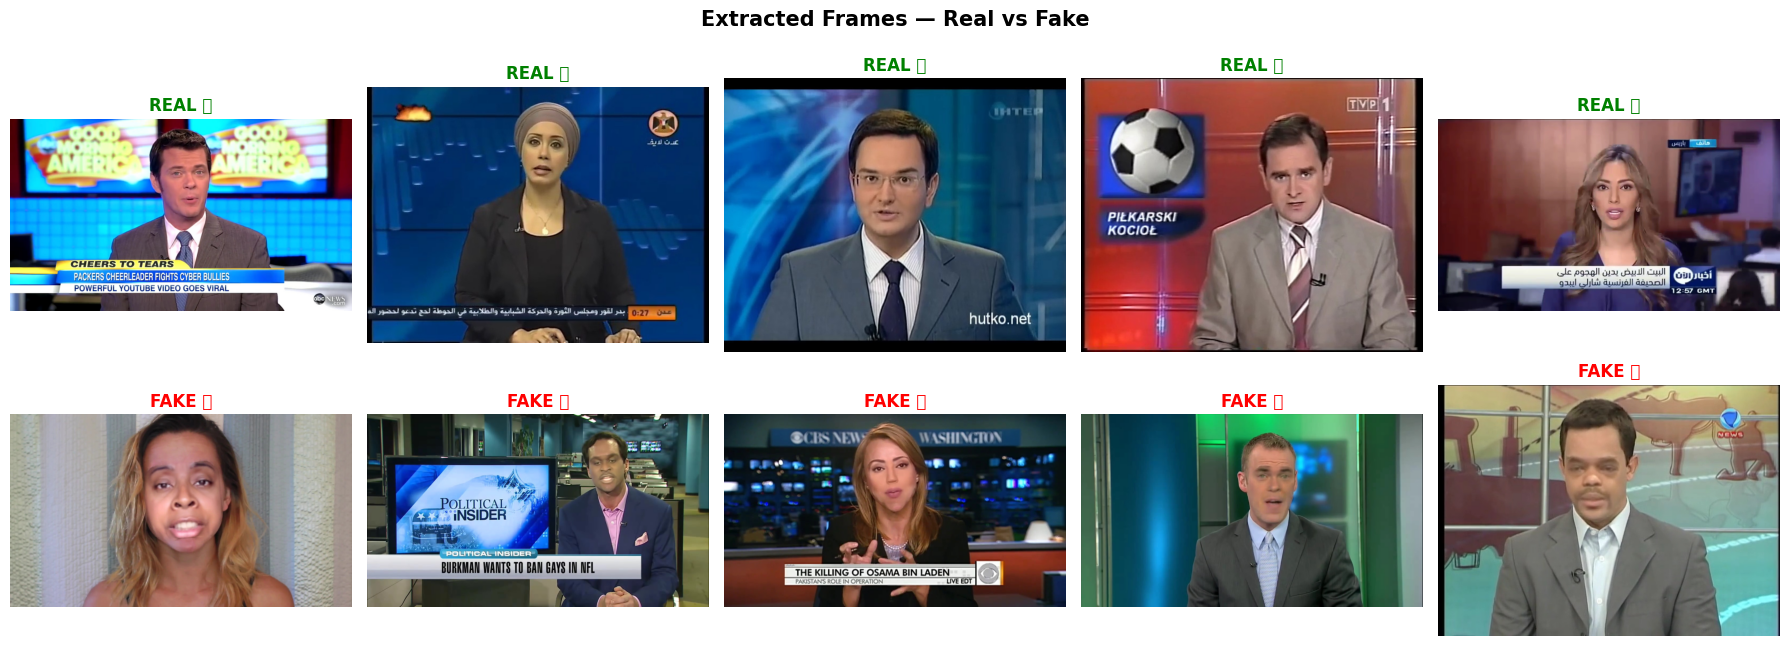

✅ Sample grid saved to Drive


In [13]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle("Extracted Frames — Real vs Fake",
             fontsize=15, fontweight='bold')

real_imgs = [p for p, l in zip(image_paths, labels) if l == 0]
fake_imgs = [p for p, l in zip(image_paths, labels) if l == 1]

for j in range(5):
    img = Image.open(random.choice(real_imgs)).convert("RGB")
    axes[0][j].imshow(img)
    axes[0][j].axis('off')
    axes[0][j].set_title("REAL ✅", color='green', fontweight='bold')

    img = Image.open(random.choice(fake_imgs)).convert("RGB")
    axes[1][j].imshow(img)
    axes[1][j].axis('off')
    axes[1][j].set_title("FAKE ❌", color='red', fontweight='bold')

plt.tight_layout()
os.makedirs("/content/drive/MyDrive/frp", exist_ok=True)
plt.savefig("/content/drive/MyDrive/frp/sample_frames.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sample grid saved to Drive")

In [14]:
# 70% Train | 15% Val | 15% Test
X_tr, X_test, y_tr, y_test = train_test_split(
    image_paths, labels,
    test_size=0.15,
    stratify=labels,
    random_state=SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X_tr, y_tr,
    test_size=0.18,
    stratify=y_tr,
    random_state=SEED
)

print(f"Train : {len(X_train)}  → Real={y_train.count(0)}, Fake={y_train.count(1)}")
print(f"Val   : {len(X_val)}   → Real={y_val.count(0)},  Fake={y_val.count(1)}")
print(f"Test  : {len(X_test)}  → Real={y_test.count(0)},  Fake={y_test.count(1)}")

Train : 697  → Real=348, Fake=349
Val   : 153   → Real=77,  Fake=76
Test  : 150  → Real=75,  Fake=75


In [15]:
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.1),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.3, contrast=0.3,
                  saturation=0.2, hue=0.05),
    T.RandomGrayscale(p=0.05),
    T.ToTensor(),
    T.Normalize(MEAN, STD)
])

val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(MEAN, STD)
])

# ── Dataset Class ────────────────────────────────────────────────
class DeepfakeDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img   = Image.open(self.paths[idx]).convert("RGB")
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        if self.transform:
            img = self.transform(img)
        return img, label

# ── DataLoaders ──────────────────────────────────────────────────
train_ds = DeepfakeDataset(X_train, y_train, train_transform)
val_ds   = DeepfakeDataset(X_val,   y_val,   val_transform)
test_ds  = DeepfakeDataset(X_test,  y_test,  val_transform)

train_loader = DataLoader(train_ds, batch_size=16,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=16,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=16,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

✅ Train: 697 | Val: 153 | Test: 150


In [16]:
class HybridCNNViT(nn.Module):
    """
    Branch 1 → EfficientNet-B0  (CNN)
                 detects local pixel artifacts & texture anomalies

    Branch 2 → ViT-Small/16     (Vision Transformer)
                 captures global facial structure relationships

    Fusion   → Concatenate (1664-d) → MLP → Real / Fake
    """
    def __init__(self, num_classes=2, dropout=0.4):
        super().__init__()

        # ── CNN Branch ───────────────────────────────────────────
        eff         = models.efficientnet_b0(pretrained=True)
        cnn_out_dim = eff.classifier[1].in_features   # 1280
        eff.classifier = nn.Identity()
        self.cnn_branch = eff

        # ── Vision Transformer Branch ────────────────────────────
        vit         = timm.create_model(
                          'vit_small_patch16_224',
                          pretrained=True,
                          num_classes=0)
        vit_out_dim = vit.num_features                # 384
        self.vit_branch = vit

        # ── Fusion Classifier ────────────────────────────────────
        fused_dim = cnn_out_dim + vit_out_dim         # 1664

        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(dropout / 2),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        cnn_feat = self.cnn_branch(x)                      # (B, 1280)
        vit_feat = self.vit_branch(x)                      # (B, 384)
        fused    = torch.cat([cnn_feat, vit_feat], dim=1)  # (B, 1664)
        return self.classifier(fused)


model = HybridCNNViT(num_classes=2).to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters()
                if p.requires_grad)

print(f"✅ Model ready")
print(f"   Total params     : {total/1e6:.2f}M")
print(f"   Trainable params : {trainable/1e6:.2f}M")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 136MB/s]
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

✅ Model ready
   Total params     : 26.66M
   Trainable params : 26.66M


In [17]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Pretrained branches get lower LR, new classifier gets higher LR
optimizer = optim.AdamW([
    {'params': model.cnn_branch.parameters(), 'lr': 5e-6},
    {'params': model.vit_branch.parameters(), 'lr': 5e-6},
    {'params': model.classifier.parameters(), 'lr': 1e-4},
], weight_decay=1e-4)

EPOCHS    = 40
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-7)

print("✅ Optimizer and scheduler configured")

✅ Optimizer and scheduler configured


In [18]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for imgs, lbls in loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == lbls).sum().item()
        total      += imgs.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out   = model(imgs)
            loss  = criterion(out, lbls)
            probs = torch.softmax(out, dim=1)[:, 1]   # P(fake)

            total_loss += loss.item() * imgs.size(0)
            correct    += (out.argmax(1) == lbls).sum().item()
            total      += imgs.size(0)

            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(lbls.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return (total_loss / total, correct / total,
            all_preds, all_labels, all_probs)

In [19]:
SAVE_PATH = "/content/drive/MyDrive/frp/best_model.pth"

history      = {"train_loss": [], "val_loss": [],
                "train_acc":  [], "val_acc":  []}
best_val_acc = 0.0
patience     = 10
patience_ctr = 0

print(f"{'Epoch':>5} | {'Tr Loss':>8} | {'Tr Acc':>7} | "
      f"{'Vl Loss':>8} | {'Vl Acc':>7}")
print("─" * 55)

for epoch in range(1, EPOCHS + 1):

    tr_loss, tr_acc = train_one_epoch(
        model, train_loader, optimizer, criterion)

    vl_loss, vl_acc, _, _, _ = evaluate(
        model, val_loader, criterion)

    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    tag = ""
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), SAVE_PATH)
        patience_ctr = 0
        tag = "  ✅ saved"
    else:
        patience_ctr += 1
        if patience_ctr >= patience:
            print(f"\n⛔ Early stopping triggered at epoch {epoch}")
            break

    print(f"{epoch:>5} | {tr_loss:>8.4f} | {tr_acc:>7.4f} | "
          f"{vl_loss:>8.4f} | {vl_acc:>7.4f}{tag}")

print(f"\n🏆 Best Validation Accuracy : {best_val_acc:.4f}")
print(f"💾 Model saved → {SAVE_PATH}")

Epoch |  Tr Loss |  Tr Acc |  Vl Loss |  Vl Acc
───────────────────────────────────────────────────────
    1 |   0.6652 |  0.6255 |   0.5556 |  0.7843  ✅ saved
    2 |   0.5461 |  0.7690 |   0.4619 |  0.8431  ✅ saved
    3 |   0.4952 |  0.7834 |   0.4282 |  0.8301
    4 |   0.4662 |  0.8192 |   0.4003 |  0.8693  ✅ saved
    5 |   0.4091 |  0.8723 |   0.3885 |  0.8366
    6 |   0.3913 |  0.8651 |   0.3581 |  0.8627
    7 |   0.3831 |  0.8666 |   0.3553 |  0.8497
    8 |   0.3804 |  0.8895 |   0.3451 |  0.8889  ✅ saved
    9 |   0.3624 |  0.8881 |   0.3422 |  0.8889
   10 |   0.3688 |  0.8852 |   0.3431 |  0.9085  ✅ saved
   11 |   0.3626 |  0.8996 |   0.3248 |  0.9281  ✅ saved
   12 |   0.3445 |  0.9082 |   0.3214 |  0.9020
   13 |   0.3416 |  0.9067 |   0.3077 |  0.9216
   14 |   0.3236 |  0.9225 |   0.3004 |  0.9216
   15 |   0.3226 |  0.9139 |   0.3108 |  0.9085
   16 |   0.3338 |  0.9283 |   0.3050 |  0.9281
   17 |   0.3299 |  0.9311 |   0.3102 |  0.9281
   18 |   0.3150 |  0.9182

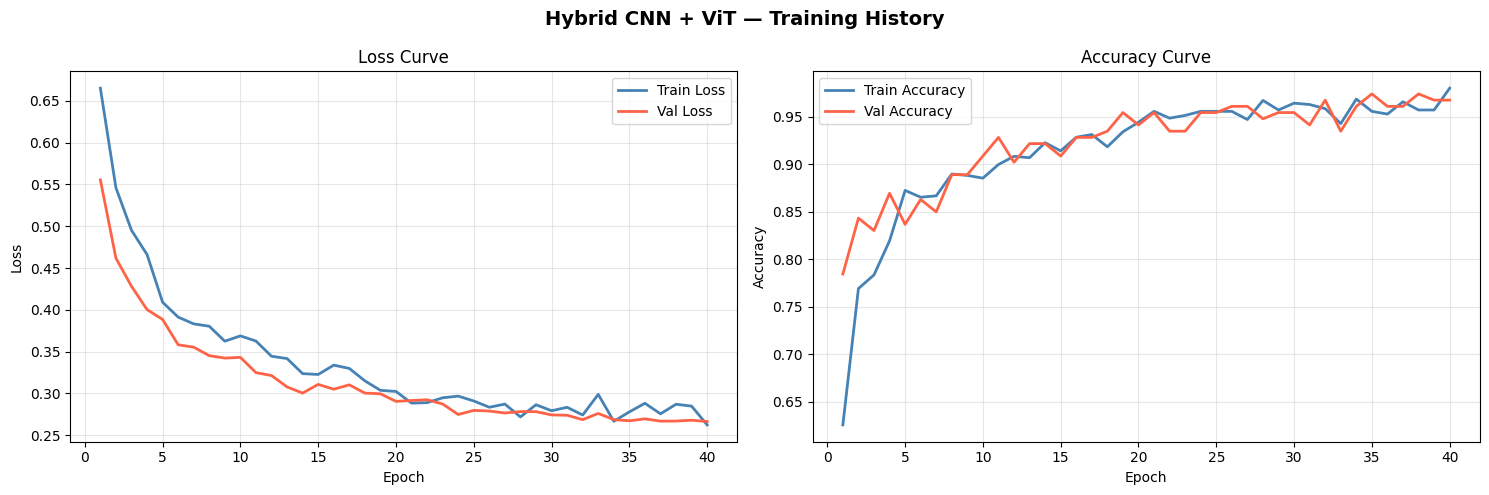

✅ Training curves saved to Drive


In [20]:
epochs_ran = len(history["train_loss"])
x = range(1, epochs_ran + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Hybrid CNN + ViT — Training History",
             fontsize=14, fontweight='bold')

ax1.plot(x, history["train_loss"], label="Train Loss",
         color='steelblue', lw=2)
ax1.plot(x, history["val_loss"],   label="Val Loss",
         color='tomato', lw=2)
ax1.set_title("Loss Curve")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(x, history["train_acc"], label="Train Accuracy",
         color='steelblue', lw=2)
ax2.plot(x, history["val_acc"],   label="Val Accuracy",
         color='tomato', lw=2)
ax2.set_title("Accuracy Curve")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/frp/training_curves.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training curves saved to Drive")

In [21]:
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))

_, test_acc, preds, true_labels, probs = evaluate(
    model, test_loader, criterion)

print(f"\n📊 Final Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)\n")
print("─" * 50)
print(classification_report(true_labels, preds,
                             target_names=["Real", "Fake"]))


📊 Final Test Accuracy : 0.9600  (96.00%)

──────────────────────────────────────────────────
              precision    recall  f1-score   support

        Real       0.99      0.93      0.96        75
        Fake       0.94      0.99      0.96        75

    accuracy                           0.96       150
   macro avg       0.96      0.96      0.96       150
weighted avg       0.96      0.96      0.96       150



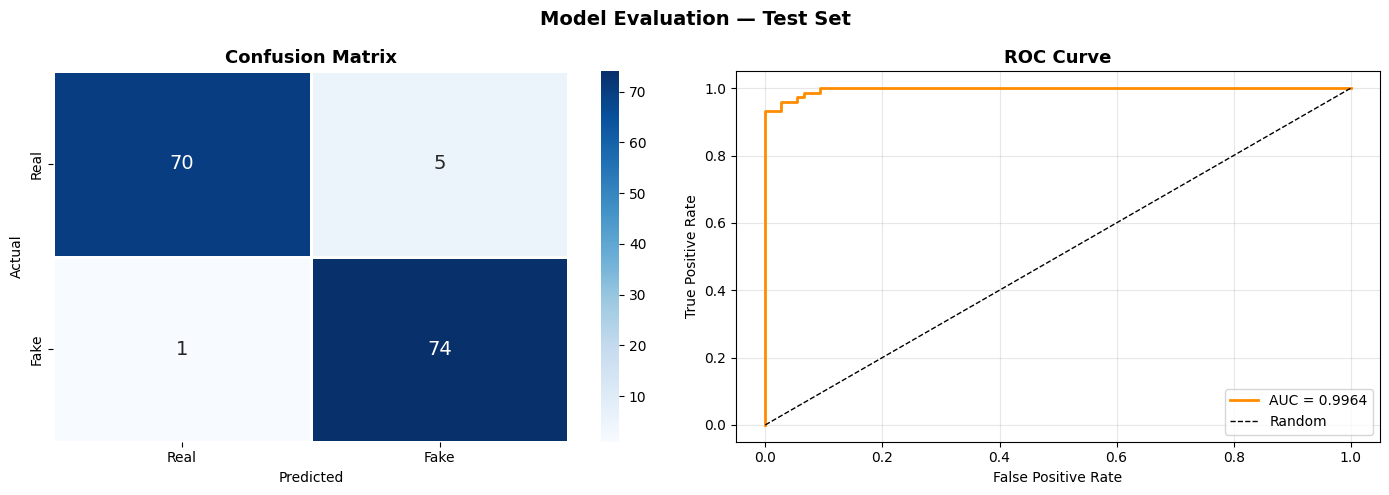

✅ Evaluation plots saved to Drive


In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model Evaluation — Test Set",
             fontsize=14, fontweight='bold')

# ── Confusion Matrix ─────────────────────────────────────────────
cm = confusion_matrix(true_labels, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=["Real", "Fake"],
            yticklabels=["Real", "Fake"],
            linewidths=1, annot_kws={"size": 14})
ax1.set_title("Confusion Matrix", fontsize=13, fontweight='bold')
ax1.set_xlabel("Predicted"); ax1.set_ylabel("Actual")

# ── ROC Curve ────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(true_labels, probs)
roc_auc     = auc(fpr, tpr)
ax2.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'AUC = {roc_auc:.4f}')
ax2.plot([0,1], [0,1], 'k--', lw=1, label='Random')
ax2.set_title("ROC Curve", fontsize=13, fontweight='bold')
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.legend(loc='lower right'); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/frp/evaluation.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Evaluation plots saved to Drive")

/tmp/ipykernel_781/2389010920.py:19: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


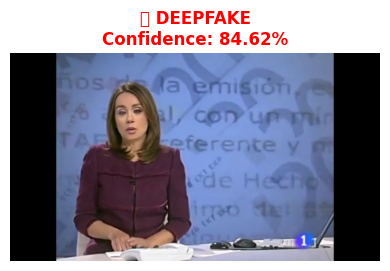

Prediction      : 🔴 DEEPFAKE
Real confidence : 0.1538 (15.38%)
Fake confidence : 0.8462 (84.62%)


In [23]:
def predict_image(img_path, model, transform, device):
    model.eval()
    img    = Image.open(img_path).convert("RGB")
    tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        out   = model(tensor)
        probs = torch.softmax(out, dim=1)[0]
        pred  = out.argmax(1).item()

    label = "🔴 DEEPFAKE" if pred == 1 else "🟢 REAL"
    conf  = probs[pred].item()

    plt.figure(figsize=(4, 4))
    plt.imshow(img); plt.axis('off')
    plt.title(f"{label}\nConfidence: {conf:.2%}",
              fontsize=12, fontweight='bold',
              color='red' if pred == 1 else 'green')
    plt.tight_layout(); plt.show()

    print(f"Prediction      : {label}")
    print(f"Real confidence : {probs[0]:.4f} ({probs[0]*100:.2f}%)")
    print(f"Fake confidence : {probs[1]:.4f} ({probs[1]*100:.2f}%)")


# ── Test on any frame ────────────────────────────────────────────
predict_image(
    random.choice([p for p, l in zip(image_paths, labels) if l == 1]),
    model, val_transform, device
)

In [24]:
model.eval()
results = []

for path, true_label in zip(X_test, y_test):
    img    = Image.open(path).convert("RGB")
    tensor = val_transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        out   = model(tensor)
        probs = torch.softmax(out, dim=1)[0]
        pred  = out.argmax(1).item()
    results.append({
        "file"      : os.path.basename(path),
        "true"      : "Real" if true_label == 0 else "Fake",
        "predicted" : "Real" if pred == 0 else "Fake",
        "correct"   : "✅" if pred == true_label else "❌",
        "confidence": f"{probs[pred].item()*100:.1f}%"
    })

# Print table
print(f"\n{'File':<35} {'True':>6} {'Pred':>6} {'OK':>4} {'Conf':>8}")
print("─" * 65)
for r in results:
    print(f"{r['file']:<35} {r['true']:>6} {r['predicted']:>6} "
          f"{r['correct']:>4} {r['confidence']:>8}")

correct = sum(1 for r in results if r['correct'] == '✅')
print(f"\n✅ {correct}/{len(results)} correct on test set")


File                                  True   Pred   OK     Conf
─────────────────────────────────────────────────────────────────
955_frame0000.jpg                     Real   Real    ✅    98.2%
975_978_frame0180.jpg                 Fake   Fake    ✅    77.0%
973_frame0159.jpg                     Real   Real    ✅    99.0%
956_frame0054.jpg                     Real   Real    ✅    96.1%
887_275_frame0033.jpg                 Fake   Fake    ✅    92.2%
865_739_frame0238.jpg                 Fake   Fake    ✅    96.6%
969_frame0315.jpg                     Real   Real    ✅    97.1%
858_861_frame0240.jpg                 Fake   Fake    ✅    93.5%
958_frame0273.jpg                     Real   Real    ✅    97.0%
981_985_frame0074.jpg                 Fake   Fake    ✅    86.2%
602_397_frame0198.jpg                 Fake   Fake    ✅    95.0%
953_frame0315.jpg                     Real   Real    ✅    92.4%
978_frame0375.jpg                     Real   Real    ✅    70.4%
994_frame0000.jpg                    